In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"

!nvidia-smi


Thu Oct 19 17:59:23 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  On   | 00000000:1A:00.0 Off |                  N/A |
| 22%   40C    P2    63W / 250W |  10799MiB / 11264MiB |      2%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  On   | 00000000:1B:00.0 Off |                  N/A |
| 22%   

In [3]:
import tensorflow as tf

tf.config.list_physical_devices("GPU")
import warnings
warnings.filterwarnings('ignore')
from contextlib import redirect_stdout, redirect_stderr
import sys
import contextlib
tf.__version__

2023-10-19 17:59:23.928228: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-19 17:59:24.100085: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-19 17:59:24.148556: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-10-19 17:59:25.742077: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

'2.10.0'

In [4]:
import gym
import numpy as np
import matplotlib.pyplot as plt

import gym
print(gym.__version__)
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from IPython import display

0.26.2


In [5]:
import tensorflow_probability as tfp


In [6]:
def preprocess(image):
    """Preprocess a frame from the game."""
    image = image[35:195]  # Crop
    image = image[::2, ::2, 0]  # Downsample by a factor of 2
    image[image == 144] = 0  # Erase background (background type 1)
    image[image == 109] = 0  # Erase background (background type 2)
    image[image != 0] = 1  # Set paddles and ball to 1, everything else to 0
    return np.reshape(image.astype(np.float32).ravel(), [80, 80])


# Neural Network 

In [7]:

# hyperparameters
learning_rate = 0.0005
gamma = 0.99
#num_episodes = 1500
render = False
#tf.get_logger().setLevel(tf.compat.v1.logging.ERROR)
#import tensorflow.compat.v1 as tf
#tf.disable_eager_execution()
#tf.logging.set_verbosity('ERROR')

env = gym.make("Pong-v0")

A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


In [8]:
env.reset()[0].shape

(210, 160, 3)

In [9]:
#env.render(mode='human')

In [10]:
checkpoint_dir = "../checkpoints/"  # Specify the directory where checkpoints will be saved
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True,  # Only save model weights, not the entire model
    save_best_only=True,  # Save only the best checkpoint (based on monitored metric)
    monitor='val_loss',  # Specify the metric to monitor for saving the best checkpoint
    verbose=1
)

In [11]:

# neural network model
'''
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(80, 80)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(200, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')])
'''

# 
'''
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(80, 80, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='linear'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')])
'''
model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=(80, 80, 2)))
#model.add(tf.keras.layers.Conv2D(2, (80,80), activation='relu'))
#model.add(tf.keras.layers.BatchNormalization())
#model.add(tf.keras.layers.MaxPooling2D((1, 1)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(256, activation='linear'))
#model.add(tf.keras.layers.Dense(256, activation='linear'))
model.add(tf.keras.layers.Dense(2, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate)
#huber_loss = tf.keras.losses.Huber()


#learning_rate = 0.0005  # You can adjust the learning rate as needed

# Weight decay
#weight_decay = 0.01  # You can adjust the weight decay as needed

# Create the AdamW optimizer
#optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, weight_decay=weight_decay)


2023-10-19 17:59:30.679572: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-19 17:59:31.556061: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9307 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:89:00.0, compute capability: 7.5


Episode: 0, Reward: -21.0
Episode: 1, Reward: -21.0
Episode: 2, Reward: -21.0
Episode: 3, Reward: -21.0
Episode: 4, Reward: -20.0
Episode: 5, Reward: -21.0
Episode: 6, Reward: -21.0
Episode: 7, Reward: -20.0
Episode: 8, Reward: -20.0
Episode: 9, Reward: -20.0
Episode: 10, Reward: -20.0
Episode: 11, Reward: -20.0
Episode: 12, Reward: -21.0
Episode: 13, Reward: -21.0
Episode: 14, Reward: -21.0
Episode: 15, Reward: -21.0
Episode: 16, Reward: -21.0
Episode: 17, Reward: -21.0
Episode: 18, Reward: -20.0
Episode: 19, Reward: -21.0
Episode: 20, Reward: -20.0
Episode: 21, Reward: -20.0
Episode: 22, Reward: -21.0
Episode: 23, Reward: -21.0
Episode: 24, Reward: -21.0
Episode: 25, Reward: -20.0
Episode: 26, Reward: -21.0
Episode: 27, Reward: -21.0
Episode: 28, Reward: -21.0
Episode: 29, Reward: -21.0
Episode: 30, Reward: -20.0
Episode: 31, Reward: -19.0
Episode: 32, Reward: -21.0
Episode: 33, Reward: -21.0
Episode: 34, Reward: -21.0
Episode: 35, Reward: -21.0
Episode: 36, Reward: -21.0
Episode: 37

ValueError: x and y must have same first dimension, but have shapes (5,) and (1000,)

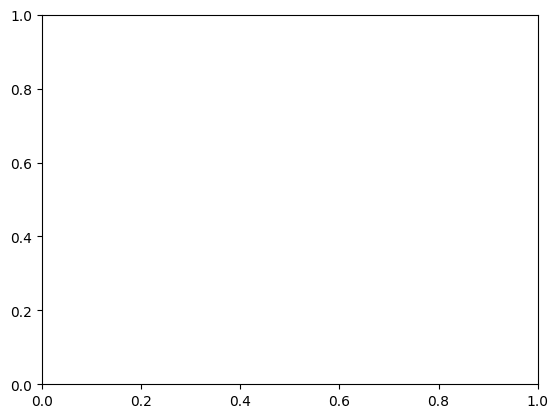

In [13]:

# training loop

last_100_episodes =[]
episode_rewards = []
for batch in range (0, 200):
    num_episodes = 5
# Training loop
    obs_history_batch = []
    reward_history_batch = []
    action_history_batch = []
    discounted_rewards_batch = []
    
    
    loss = 0
    with tf.GradientTape() as tape:
        #tape.watch(model.trainable_variables)
    
        for episode in range(num_episodes):
            obs_history_eps = []
            reward_history_eps = []
            action_history_eps = []
            selected_probs_eps = []
            
            index_history_eps = []
            prob_output_eps = tf.Variable(tf.zeros([0, 2], dtype=tf.float32))

            
            state = preprocess(env.reset()[0])
            prev_state = state
            episode_reward = 0
            #reward_history = []
            action_probs = []
            #selected_probs_eps = []
    
            terminated = False
            truncated = False 

        #with tf.GradientTape() as tape:

            while (not terminated) and (not truncated):

                # Predict the probability of each action
                with open('output.log', 'w') as log_file:
                    with contextlib.redirect_stdout(log_file), contextlib.redirect_stderr(log_file):
                        if episode_reward==0:
                            combined_states = tf.stack([tf.convert_to_tensor(prev_state), tf.convert_to_tensor(prev_state)], axis=-1)
                            action_prob = model(np.expand_dims(combined_states, axis=0))[0]
                        else: 
                            action_prob = model(np.expand_dims(combined_states, axis=0))[0]

                #print(action_prob)
                ##normalize the probabilities because they don't sum to 1
                #action_prob /= np.sum(action_prob)
                #action = np.random.choice([2, 3], p=action_prob)
                #action = np.where(np.random.multinomial(1, action_prob) == 1)[0][0] + 2
                dist = tfp.distributions.Categorical(probs=action_prob, dtype=tf.float32)
                action = dist.sample()
                #print(int(action))
                if int(action)==0:
                    a=2
                elif int(action)==1:
                    a=3
                    
                #print(a)
                
                index_history_eps.append(int(action))
                prob_output_eps = tf.concat([prob_output_eps, tf.expand_dims(action_prob, 0)], axis=0)

                #print(prob_output_eps)
                
                
                action_probs.append(action_prob)
                selected_probs_eps.append(action_prob[int(action)])
                # Take the chosen action
                next_state, reward, terminated, truncated, info = env.step(a)
                reward_history_eps.append(reward)
                action_history_eps.append(a)
                reward_history_batch.append(reward)
                action_history_batch.append(a)


                #print(f"CartPole-v0, episode {episode + batch*20}, score {sum(reward_history_eps)}")
                
                next_state = preprocess(next_state)
                episode_reward += reward
                #reward_history.append(reward)
                combined_states = tf.stack([tf.convert_to_tensor(prev_state), tf.convert_to_tensor(next_state)], axis=-1)
                obs_history_eps.append(combined_states)
                
                prev_state = next_state
                #if terminated or truncated:
                    #episode_rewards.append(episode_reward)
            episode_rewards.append(episode_reward)
            print(f"Episode: {episode+batch*num_episodes}, Reward: {episode_reward}")
            if len(episode_rewards) >= 100:
                avg_reward = np.mean(episode_rewards[-100:])
                print(f"Average Reward (Last 100 Episodes): {avg_reward}")
                    #break
    #after the end of the episode   
            discounted_rewards_eps = []
            reward_sum = 0
            for r in reward_history_eps[::-1]:
                reward_sum = r + gamma * reward_sum
                discounted_rewards_eps.insert(0, reward_sum)
                
                
            
            #predicted_action_prob = model(np.expand_dims(combined_states, axis=0)) #shape of two
            #loss = -tf.reduce_sum(tf.math.log(predicted_action_prob[0][a]) *discounted_rewards)
            discounted_rewards_eps = np.array(discounted_rewards_eps)
            reshaped_discounted_rewards = discounted_rewards_eps.reshape(-1, 1)
            #tensor_logprob = tf.math.log(tf.convert_to_t(selected_probs_eps, dtype=tf.float32))
            
            
            #probs_tensor = tf.math.log(model(np.expand_dims(obs_history_eps, axis=0))[0])
            #selecting probs
            index_history_eps = tf.cast(index_history_eps, dtype=tf.int32)  # Or tf.int64, depending on your needs

            selected_values = tf.math.log(tf.gather(prob_output_eps, index_history_eps, axis=1))
            
            tensor_logprob = tf.math.log(tf.convert_to_tensor(selected_probs_eps, dtype=tf.float32))
            tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)
            ###normalize the discounted rewards
            mean = tf.reduce_mean(tensor_rewards)
            std = tf.math.reduce_std(tensor_rewards)

            # Normalize the discounted rewards
            normalized_rewards = (tensor_rewards - mean) / (std + 1e-8)
            tensor_rewards_normalized = tf.convert_to_tensor(normalized_rewards, dtype=tf.float32)
            
            #loss =loss +  tf.reduce_sum (index_history_eps * tensor_rewards_normalized)
            for idx in range (0, tensor_rewards_normalized.shape[0]):
                loss = loss + tensor_rewards_normalized[idx] * tf.math.log(prob_output_eps[idx][int(index_history_eps[idx])])
            
            
        ##After one batch 
        
        loss = -tf.convert_to_tensor(loss)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Calculate the simple moving average of the last 100 episode rewards
    

env.close()
'''
# plot the episode rewards and their moving average
episode_numbers = list(range(1, num_episodes + 1))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")
if len(episode_rewards) >= 100:
    moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
    plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()
'''
episode_numbers = list(range(1, len(episode_rewards) + 1))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")
moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()


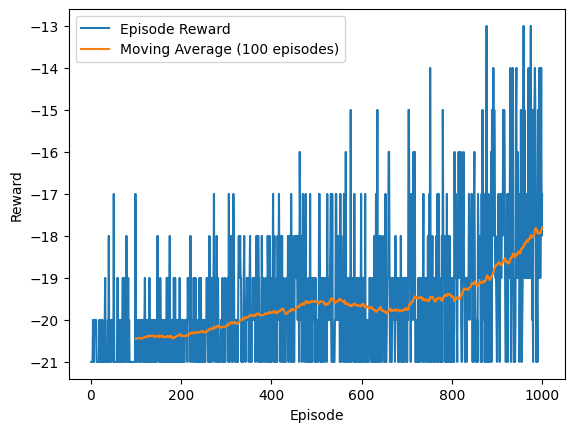

In [14]:
episode_numbers = list(range(1, len(episode_rewards) + 1))
plt.plot(episode_numbers, episode_rewards, label="Episode Reward")
moving_avg = np.convolve(episode_rewards, np.ones(100) / 100, mode='valid')
plt.plot(episode_numbers[-len(moving_avg):], moving_avg, label="Moving Average (100 episodes)")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()